<a href="https://colab.research.google.com/github/Areca293/Evaluating-the-Isolation-Forest-unsupervised-anomaly-detector-of-onEEGWaveLAD/blob/main/onEEGwaveLAD_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# ==========================================
# Setup & Imports
# ==========================================
!pip install mne isotree

import pathlib as pl
import numpy as np
import mne
import pywt
import pandas as pd
from isotree import IsolationForest
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

print("Libraries imported and Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported and Google Drive mounted successfully.


In [56]:
# ==========================================
# Dataset Loading
# ==========================================
import pathlib as pl
import mne

def loadDataset(name, subject, montageName, usedChannels, rootPath, montageChannelNames, parametersOfDenoiser=None, verbose=False):
    """
    Loads the EEG dataset according to the pre-defined folder structure.
    Extracts the shifted data version for temporal alignment.
    """
    dataset = pl.Path(name)
    subject = str(subject)
    root = pl.Path(rootPath)

    # Construct the file pathway for raw EEG data files
    pathDataset = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/")
    filenameSubject = pl.Path(subject + "_" + dataset.name + "_" + "shifted.set")
    pathDatasetSubject = pl.Path.joinpath(pathDataset, subject, filenameSubject)

    # Construct the file pathway for the EEG sensor coordinate (Montage) file
    filenameMontage = pl.Path(str("standard-10-5-cap385.elp"))
    montagePath = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/", "EEG_ERP_Processing", filenameMontage)

    # Ingest EEGLAB format files using the MNE framework
    dataForSubject = mne.io.read_raw_eeglab(pathDatasetSubject, preload=True)
    dataForSubject.rename_channels(lambda s: s.strip("."))

    channels = dataForSubject.info["ch_names"]
    sampleFreq = dataForSubject.info["sfreq"]

    if verbose:
        print("Data summary before pre-processing: {}".format(dataForSubject))
        print("Metadata structure before pre-processing: {}".format(dataForSubject.info))

        print("Loading file: " + str(filenameSubject))
        print("Root path: ", root)
        print("Dataset directory: ", pathDataset)
        print("Subject path location: ", pathDatasetSubject)
        print("Montage file path: ", montagePath)
        print("Data successfully loaded for subject: {}".format(subject))
        print("Identified channels: {}".format(channels))

        # Output experimental event markings and stimulus annotations
        print("Annotations data: " + str(dataForSubject.annotations))
        print("Annotation durations shape: " + str(dataForSubject.annotations.duration.shape))
        print("Annotation descriptions shape: " + str(dataForSubject.annotations.description.shape))
        print("Annotation onsets shape: " + str(dataForSubject.annotations.onset.shape))
        if len(dataForSubject.annotations.onset) > 0:
            print("Initial event timestamp: " + str(dataForSubject.annotations.onset[0]))
        print(list(dataForSubject.annotations.description))

        # Render raw EEG signal configurations
        dataForSubject.plot()

    return dataForSubject

In [57]:
# ==========================================
# Step A: EEG Windowing Configuration
# ==========================================
class OnEEGWaveLAD_Windowing:
    def __init__(self, raw_data, RTWL=1000):
        self.raw = raw_data
        self.Sr = raw_data.info['sfreq'] # Sampling frequency (Hz)
        self.RTWL = RTWL                 # Target Real-Time Window Length (ms)

        # Compute the theoretical sample points for the designated window duration
        theoretical_samples = (self.RTWL / 1000.0) * self.Sr

        # Adjust the sample count to the nearest upper power of 2 to optimize wavelet operations
        self.window_samples = int(2 ** np.ceil(np.log2(theoretical_samples)))

        # Derive the actual processing window length in milliseconds
        self.actual_RTWL = (self.window_samples / self.Sr) * 1000.0

        print(f"[Phase A] Target processing window length: {self.RTWL} ms")
        print(f"[Phase A] Adjusted operational window length: {self.actual_RTWL:.2f} ms ({self.window_samples} samples).")

        self.total_samples = raw_data.n_times

    def get_window_stream(self):
        """
        Sequentially partitions the continuous EEG signal into discrete windows.
        Yields segments as a localized data structure simulating real-time streaming blocks.
        """
        for start_idx in range(0, self.total_samples, self.window_samples):
            end_idx = start_idx + self.window_samples
            if end_idx > self.total_samples:
                break

            curr_window, _ = self.raw[:, start_idx:end_idx]

            yield {
                "start_idx": start_idx,
                "end_idx": end_idx,
                "original_window": curr_window,
                "dwt_input": curr_window
            }

## Step B: Multi-level Decomposition
Applies the Pyramidal Sub-band Coding scheme using the Discrete Wavelet Transform (DWT). The EEG window is decomposed into its constituent frequency sub-bands (approximation and detail coefficients) using a specified Mother Wavelet (`MW`).

In [58]:
# ==========================================
# Step B: Multi-level Discrete Wavelet Decomposition
# ==========================================
class OnEEGWaveLAD_DWT:
    def __init__(self, MW='sym4', decomposition_level=None):
        self.MW = MW
        self.level = decomposition_level

    def decompose_window(self, dwt_input_data):
        signal_length = dwt_input_data.shape[1]

        if self.level is None:
            # Determine the maximum mathematically valid decomposition level for the selected mother wavelet
            max_level = pywt.dwt_max_level(signal_length, self.MW)
            # Select the optimal decomposition level constrained by the signal boundary conditions
            actual_level = min(int(np.log2(signal_length)), max_level)
        else:
            actual_level = self.level

        return [pywt.wavedec(dwt_input_data[ch], self.MW, level=actual_level, mode='periodization')
                for ch in range(dwt_input_data.shape[0])]

In [59]:
# =================================================================
# Steps C - G: Multi-scale Anomaly Detection and Signal Reconstruction
# =================================================================
from isotree import IsolationForest
import numpy as np
import pywt

class OnEEGWaveLAD_Denoiser:
    def __init__(self, n_channels, Bs=10, IFt=100, IFS=512, Ta=0.50, Es=35, el=None):
        self.n_channels = n_channels
        self.Bs = Bs
        self.IFt = IFt
        self.IFS = IFS
        self.Ta = Ta
        self.Es = Es
        self.el = el

        self.buffers = [[] for _ in range(n_channels)]
        self.models = [None for _ in range(n_channels)]
        self.centroids = [None] * n_channels
        self.max_dists = [None] * n_channels

    def process_window(self, all_channels_coeffs, target_len, MW='sym4', return_debug=False, debug_channel=0):
        denoised_signals = []
        debug_info = {}
        n_isps = target_len // 2

        for ch in range(self.n_channels):
            coeffs = all_channels_coeffs[ch]

            # Separate baseline approximation coefficients (cA) from detail coefficients (cD)
            cA_baseline = coeffs[0]
            details = coeffs[1:]
            num_scales = len(details)

            # Construct the multi-scale scaleogram matrix using detail coefficients
            raw_scaleogram = np.zeros((n_isps, num_scales))
            norm_scaleogram = np.zeros((n_isps, num_scales))

            for i, c in enumerate(details):
                m_level = num_scales - i
                repeats = n_isps // len(c)
                upsampled = np.repeat(c, repeats)

                raw_scaleogram[:, i] = upsampled
                norm_scaleogram[:, i] = upsampled / (2 ** m_level)

            if return_debug and ch == debug_channel:
                debug_info['Step_C_Scaleogram_Before'] = norm_scaleogram.copy()

            # [Step E] Outlier Scoring via Extended Isolation Forest
            if self.models[ch] is not None:
                scores = self.models[ch].predict(norm_scaleogram)
            else:
                scores = np.zeros(n_isps)

            if return_debug and ch == debug_channel:
                debug_info['Step_E_Scores'] = scores.copy()

            # [Step D] Buffer Management and Model Refinement
            self.buffers[ch].append(norm_scaleogram)
            if len(self.buffers[ch]) > self.Bs:
                self.buffers[ch].pop(0)

            buffer_data = np.vstack(self.buffers[ch])

            self.centroids[ch] = np.mean(buffer_data, axis=0)
            self.max_dists[ch] = np.max(np.abs(buffer_data - self.centroids[ch]), axis=0) + 1e-8

            if buffer_data.shape[0] >= self.IFS:
                c_dim = buffer_data.shape[1]
                actual_ndim = c_dim if self.el is None else min(self.el + 1, c_dim)
                self.models[ch] = IsolationForest(ntrees=self.IFt, sample_size=self.IFS, ndim=actual_ndim, random_seed=42)
                self.models[ch].fit(buffer_data)

            # [Step F] Artifact Mitigation via Scale-Specific Attenuation
            AT_exp = {idx + e for idx in np.where(scores > self.Ta)[0]
                      for e in range(-self.Es, self.Es + 1) if 0 <= idx + e < n_isps}

            mitigator_matrix = np.ones((n_isps, num_scales))

            for idx in AT_exp:
                dist_vec = np.abs(norm_scaleogram[idx] - self.centroids[ch])
                mtga_vec = 1.0 - (dist_vec / self.max_dists[ch])
                mtga_vec = np.clip(mtga_vec, 0.0, 1.0)
                mitigator_matrix[idx] = np.minimum(mitigator_matrix[idx], mtga_vec)

            if return_debug and ch == debug_channel:
                debug_info['Step_F_Mitigator'] = mitigator_matrix.copy()

            # Apply attenuation modifiers exclusively to the details matrix
            denoised_scaleogram = raw_scaleogram * mitigator_matrix

            if return_debug and ch == debug_channel:
                mod_norm_scaleogram = np.zeros_like(denoised_scaleogram)
                for i in range(num_scales):
                    m_level = num_scales - i
                    mod_norm_scaleogram[:, i] = denoised_scaleogram[:, i] / (2 ** m_level)
                debug_info['Step_C_Scaleogram_After'] = mod_norm_scaleogram

            # [Step G] Multi-level Inverse Wavelet Reconstruction
            # Recombine the preserved baseline approximation coefficients with the mitigated detail segments
            reconstructed_coeffs = [cA_baseline.copy()]

            for i in range(num_scales):
                repeats = n_isps // len(details[i])
                expanded_row = denoised_scaleogram[:, i]
                unique_coeffs = expanded_row[::repeats]
                reconstructed_coeffs.append(unique_coeffs)

            clean_sig = pywt.waverec(reconstructed_coeffs, MW, mode='periodization')
            denoised_signals.append(clean_sig[:target_len])

        if return_debug:
            return np.array(denoised_signals), debug_info
        return np.array(denoised_signals)

In [60]:
# ==========================================
# Batch Evaluator
# ==========================================
class OnEEGWaveLAD_BatchEvaluator:
    def __init__(self, original, denoised, window_size):
        self.orig = original
        self.denoised = denoised
        self.w_size = window_size
        self.num_windows = self.orig.shape[1] // self.w_size

    def get_metrics(self, channel_idx, thresh=90):
        """
        Computes JSD and SNR parameters for classified target segments (artifacts vs clean).
        """
        orig_ch = self.orig[channel_idx] * 1e6
        denoised_ch = self.denoised[channel_idx] * 1e6
        jsd_tps, jsd_tns, snr_tps, snr_tns = [], [], [], []

        for i in range(self.num_windows):
            start, end = i * self.w_size, (i + 1) * self.w_size
            w_o, w_d = orig_ch[start:end], denoised_ch[start:end]

            # Calculate Jensen-Shannon Divergence metrics
            min_v, max_v = min(np.min(w_o), np.min(w_d)), max(np.max(w_o), np.max(w_d))
            edges = np.linspace(min_v, max_v, 51)
            p, _ = np.histogram(w_o, bins=edges, density=True)
            q, _ = np.histogram(w_d, bins=edges, density=True)
            jsd_val = jensenshannon((p + 1e-10)/np.sum(p+1e-10), (q + 1e-10)/np.sum(q+1e-10)) ** 2

            # Estimate Signal-to-Noise Ratio (SNR) variance parameters
            v_sig, v_noise = np.var(w_d), np.var(w_o - w_d)
            snr_val = float('inf') if v_noise < 1e-10 else 10 * np.log10(v_sig / v_noise)

            # Map validation segments according to magnitude bounds
            if np.max(np.abs(w_o)) > thresh:
                jsd_tps.append(jsd_val)
                snr_tps.append(snr_val)
            else:
                jsd_tns.append(jsd_val)
                snr_tns.append(snr_val)

        f_snr_tps = [v for v in snr_tps if v != float('inf')]
        f_snr_tns = [v for v in snr_tns if v != float('inf')]

        return {
            "Total_Windows": self.num_windows,
            "Blink_Windows_(TPs)": len(jsd_tps),
            "Clean_Windows_(TNs)": len(jsd_tns),
            "Avg_JSD_TPs": np.mean(jsd_tps) if jsd_tps else np.nan,
            "Avg_JSD_TNs": np.mean(jsd_tns) if jsd_tns else np.nan,
            "Avg_SNR_TPs_dB": np.mean(f_snr_tps) if f_snr_tps else np.nan,
            "Avg_SNR_TNs_dB": np.mean(f_snr_tns) if f_snr_tns else 999.99
        }

print("onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.")

onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.


Initiating dataset ingestion and pipeline parameters mapping...
Reading /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.fdt
Reading 0 ... 699391  =      0.000 ...   682.999 secs...
Data summary before pre-processing: <RawEEGLAB | 1_N170_shifted.fdt, 33 x 699392 (683.0 s), ~176.1 MiB, data loaded>
Metadata structure before pre-processing: <Info | 8 non-empty values
 bads: []
 ch_names: FP1, F3, F7, FC3, C3, C5, P3, P7, P9, PO7, PO3, O1, Oz, Pz, CPz, ...
 chs: 33 EEG
 custom_ref_applied: False
 dig: 33 items (33 EEG)
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: unspecified
 nchan: 33
 projs: []
 sfreq: 1024.0 Hz
>
Loading file: 1_N170_shifted.set
Root path:  /content/drive/MyDrive
Dataset directory:  /content/drive/MyDrive/N170 All Data and Scripts
Subject path location:  /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.set
Montage file path:  /content/drive/MyDrive/N170 All Data and Scripts/EEG_ERP_Processing/standard-10-5-cap385.elp
Data successfu

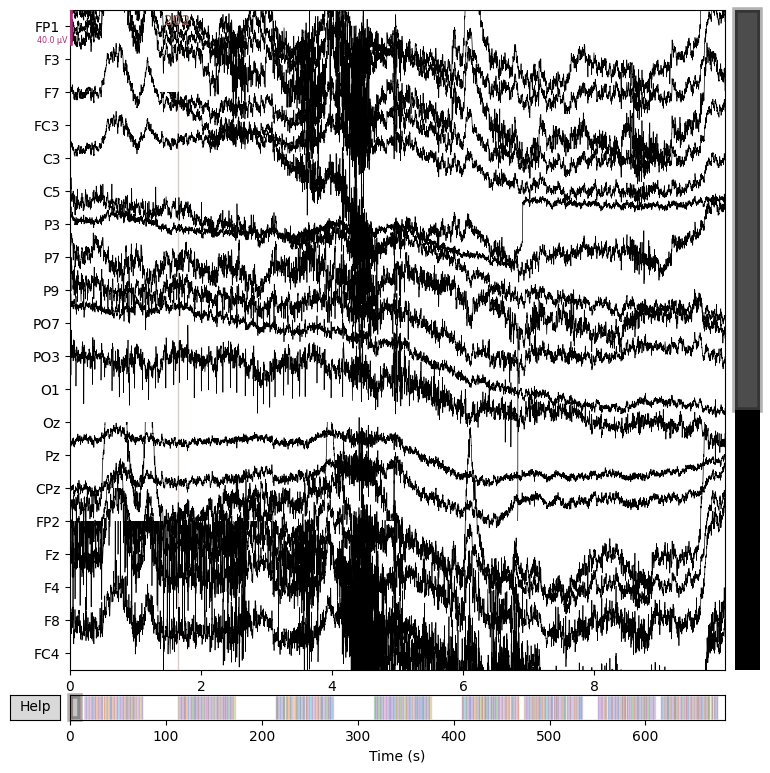

Initializing localized processing structures...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).
Executing continuous operational monitoring loop on channel: FP1
Structural anomaly instance captured within frame index 1. Terminating execution block for profiling analysis.


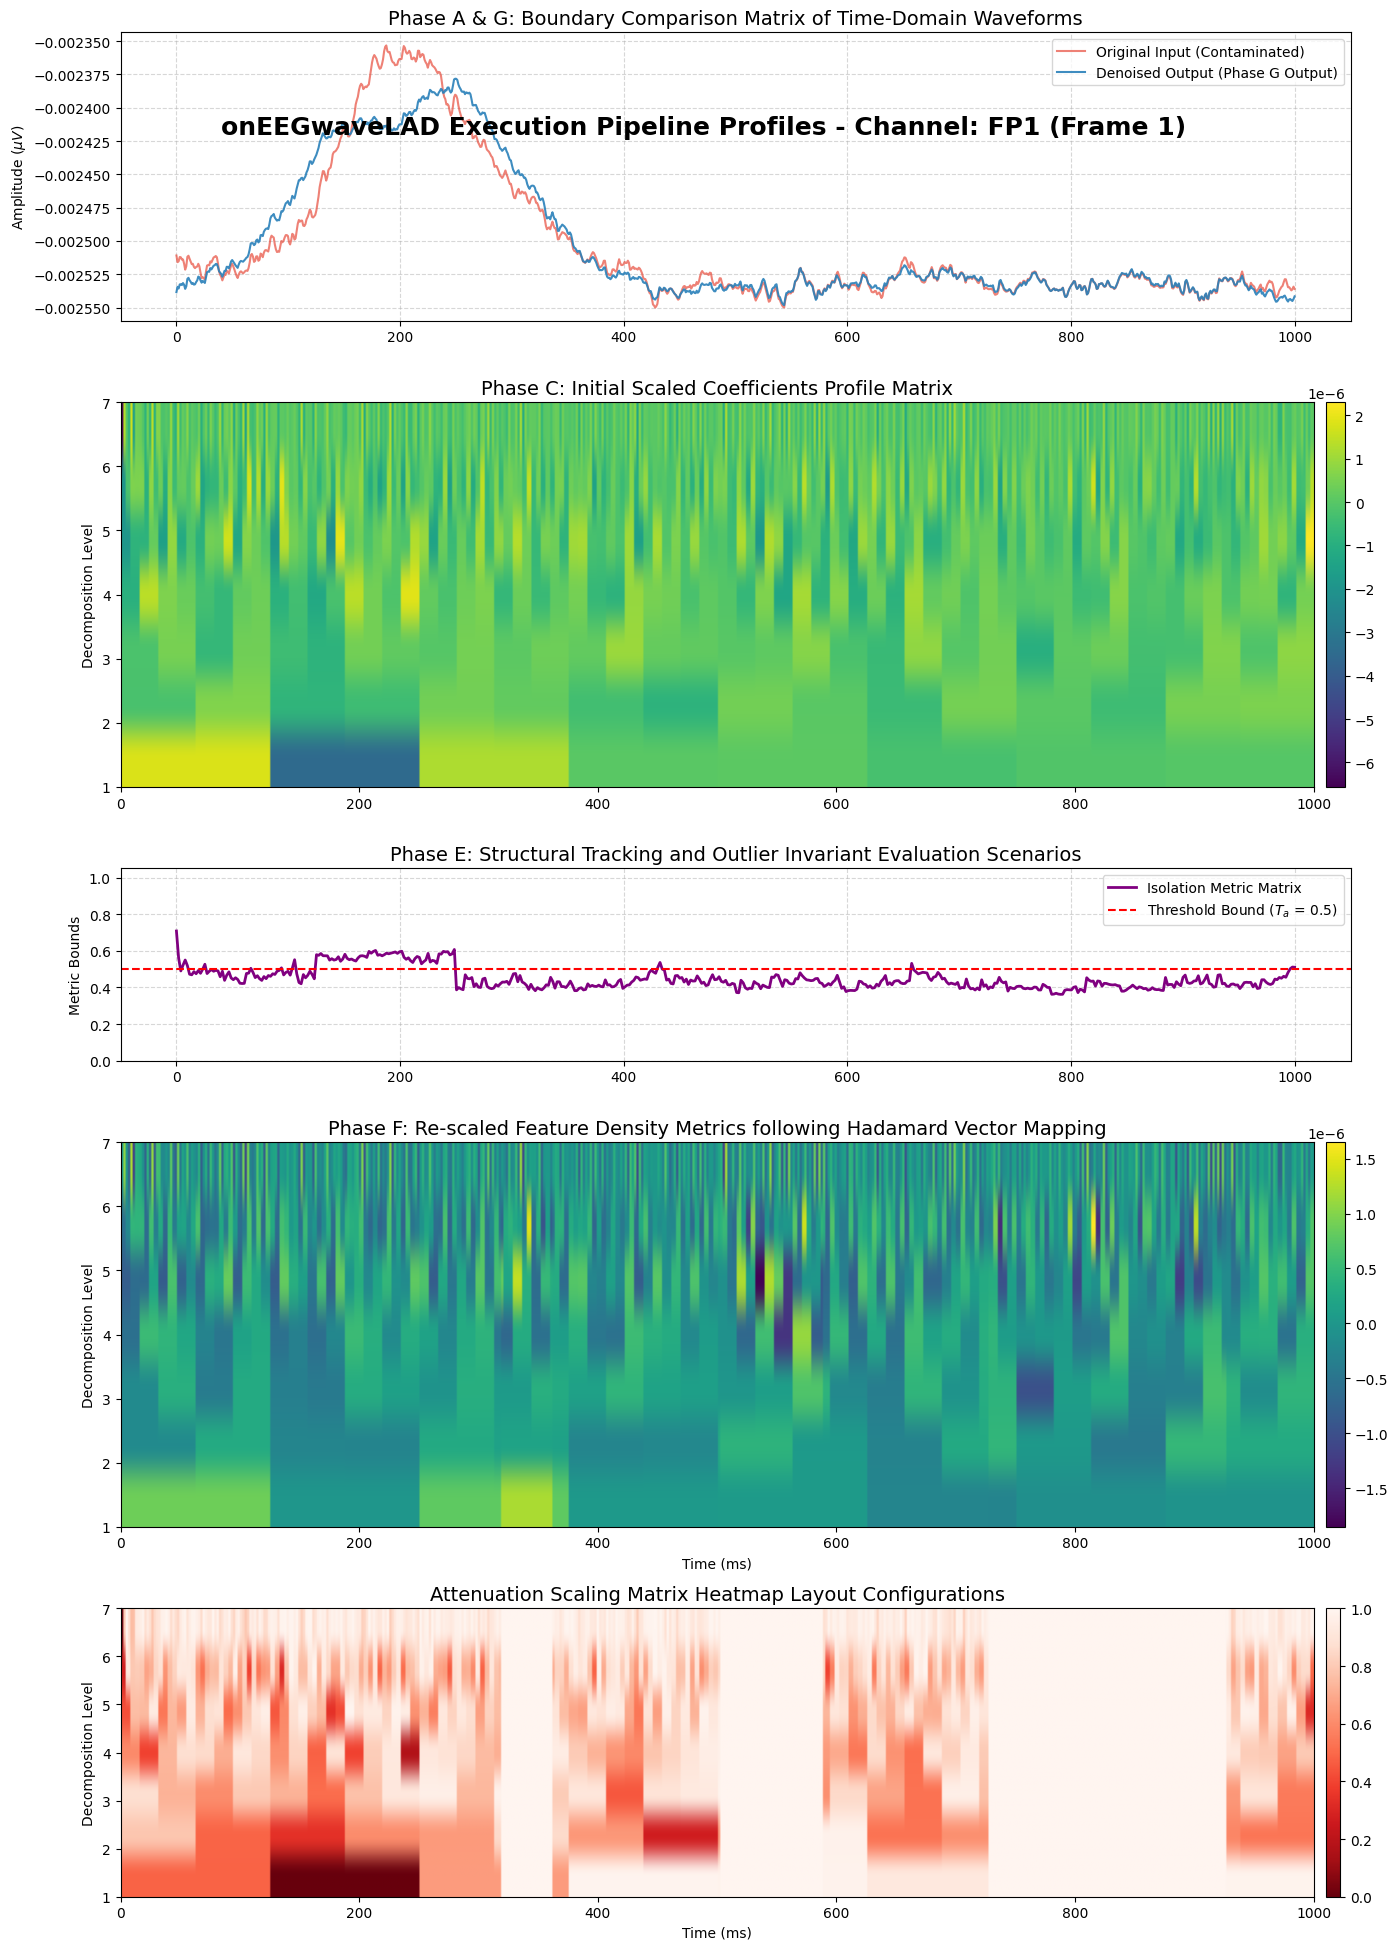

In [61]:
# ==========================================
# 1. Pipeline Configuration & Data Ingestion
# ==========================================
datasetName = "N170"
subject_id = "1"
rootPath = "/content/drive/MyDrive/"

# Configuration mappings for standard channels and montages
montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
parametersOfDenoiser = None

print("Initiating dataset ingestion and pipeline parameters mapping...")

# Read source files using structural specifications
raw_data = loadDataset(
    name=datasetName,
    subject=subject_id,
    montageName=montageName,
    usedChannels=usedChannels,
    rootPath=rootPath,
    montageChannelNames=montageChannelNames,
    parametersOfDenoiser=parametersOfDenoiser,
    verbose=True
)

# ==========================================
# 2. Framework Component Initialization
# ==========================================
print("Initializing localized processing structures...")
# Phase A: Signal segmentation configuration
windowing = OnEEGWaveLAD_Windowing(raw_data, RTWL=1000)

# Phase B: Wavelet feature transformation mapping
dwt = OnEEGWaveLAD_DWT(MW='sym4')

# Phase C-G: Algorithmic identification and modeling configuration
num_channels = len(raw_data.ch_names)
denoiser = OnEEGWaveLAD_Denoiser(n_channels=num_channels, Bs=10, IFS=512, Ta=0.50, Es=35)

# Isolate ocular signal channel profiles for validation monitoring
target_channel_name = 'Fp1'
if target_channel_name in raw_data.ch_names:
    debug_ch_idx = raw_data.ch_names.index(target_channel_name)
else:
    debug_ch_idx = 0

target_debug_info = None
target_original_sig = None
target_denoised_sig = None
target_window_idx = -1

# ==========================================
# 3. Pseudo-Real-Time Data Stream Execution
# ==========================================
print(f"Executing continuous operational monitoring loop on channel: {raw_data.ch_names[debug_ch_idx]}")

for i, win in enumerate(windowing.get_window_stream()):
    # Phase B Execution
    coeffs = dwt.decompose_window(win['dwt_input'])

    # Phase C - G Processing
    clean_sig_matrix, debug = denoiser.process_window(
        all_channels_coeffs=coeffs,
        target_len=win['original_window'].shape[1],
        return_debug=True,
        debug_channel=debug_ch_idx
    )

    # Condition criteria: Trace structural anomalies when metric metrics cross bounds
    scores = debug.get('Step_E_Scores')
    if scores is not None and np.max(scores) > denoiser.Ta:
        target_window_idx = i
        target_debug_info = debug
        target_original_sig = win['original_window'][debug_ch_idx]
        target_denoised_sig = clean_sig_matrix[debug_ch_idx]
        print(f"Structural anomaly instance captured within frame index {i}. Terminating execution block for profiling analysis.")
        break

# ==========================================
# 4. Statistical Visualization and Diagnostics
# ==========================================
if target_debug_info is not None:
    fig, axes = plt.subplots(5, 1, figsize=(14, 20), gridspec_kw={'height_ratios': [1.5, 2, 1, 2, 1.5]})
    fig.suptitle(f"onEEGwaveLAD Execution Pipeline Profiles - Channel: {raw_data.ch_names[debug_ch_idx]} (Frame {target_window_idx})", fontsize=18, fontweight='bold', y=0.92)

    time_axis = np.linspace(0, windowing.actual_RTWL, len(target_original_sig))
    isp_time_axis = np.linspace(0, windowing.actual_RTWL, len(target_debug_info['Step_E_Scores']))

    # Plot 1: Phase A & G (Temporal wave comparisons: Target vs Reconstructed data states)
    axes[0].plot(time_axis, target_original_sig, label="Original Input (Contaminated)", color='#e74c3c', alpha=0.7, linewidth=1.5)
    axes[0].plot(time_axis, target_denoised_sig, label="Denoised Output (Phase G Output)", color='#2980b9', alpha=0.9, linewidth=1.5)
    axes[0].set_title("Phase A & G: Boundary Comparison Matrix of Time-Domain Waveforms", fontsize=14)
    axes[0].set_ylabel(r"Amplitude ($\mu V$)")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Phase C (Input distribution characteristics)
    sc_before = target_debug_info['Step_C_Scaleogram_Before'].T
    im1 = axes[1].imshow(sc_before, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_before.shape[0]])
    axes[1].set_title("Phase C: Initial Scaled Coefficients Profile Matrix", fontsize=14)
    axes[1].set_ylabel("Decomposition Level")
    fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.01)

    # Plot 3: Phase D & E (Mathematical anomaly profiling scores)
    axes[2].plot(isp_time_axis, target_debug_info['Step_E_Scores'], color='purple', linewidth=2, label='Isolation Metric Matrix')
    axes[2].axhline(y=denoiser.Ta, color='red', linestyle='--', label=f'Threshold Bound ($T_a$ = {denoiser.Ta})')
    axes[2].set_title("Phase E: Structural Tracking and Outlier Invariant Evaluation Scenarios", fontsize=14)
    axes[2].set_ylabel("Metric Bounds")
    axes[2].set_ylim(0, 1.05)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, linestyle='--', alpha=0.5)

    # Plot 4: Phase F (Post-attenuation structural profiles)
    sc_after = target_debug_info['Step_C_Scaleogram_After'].T
    im2 = axes[3].imshow(sc_after, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_after.shape[0]])
    axes[3].set_title("Phase F: Re-scaled Feature Density Metrics following Hadamard Vector Mapping", fontsize=14)
    axes[3].set_ylabel("Decomposition Level")
    axes[3].set_xlabel("Time (ms)")
    fig.colorbar(im2, ax=axes[3], fraction=0.02, pad=0.01)

    # Plot 5: Phase F (Attenuation matrix evaluation profiles)
    mitigator = target_debug_info['Step_F_Mitigator'].T
    im3 = axes[4].imshow(mitigator, aspect='auto', cmap='Reds_r', origin='lower', vmin=0, vmax=1, extent=[0, windowing.actual_RTWL, 1, mitigator.shape[0]])
    axes[4].set_title("Attenuation Scaling Matrix Heatmap Layout Configurations", fontsize=14)
    axes[4].set_ylabel("Decomposition Level")
    axes[4].set_xlabel("Time (ms)")
    fig.colorbar(im3, ax=axes[4], fraction=0.02, pad=0.01)

    plt.tight_layout()
    plt.show()
else:
    print("The processing sample buffer requires continuous loading frames, or standard target parameters did not shift past the threshold criteria.")